# Proyecto de clasificador de si un objeto es biodegradable o no

Dataset usado : 
Non and Biodegradable Material Dataset
https://www.kaggle.com/datasets/rayhanzamzamy/non-and-biodegradable-waste-dataset?select=TEST
# caracteristicas
256k archivos

resolucion de 200x200

ia de apoyo DeepSeek

Estudiante: Arancibia Estrada Alvaro David

In [1]:
import torch 
import torchvision

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
device

'cuda'

In [5]:
# Rutas a tus carpetas locales
PATH_TRAIN = 'C:/Users/aaran/Downloads/Conjunto de datos de materiales no y biodegradables/TRAIN'
PATH_TEST = 'C:/Users/aaran/Downloads/Conjunto de datos de materiales no y biodegradables/TEST'

dataloader = {
    'train': torch.utils.data.DataLoader(
        torchvision.datasets.ImageFolder(
            root=PATH_TRAIN,
            transform=torchvision.transforms.Compose([
                torchvision.transforms.Resize((200, 200)), # Ajusta la resolución
                torchvision.transforms.ToTensor(),
                # Normalización estándar para imágenes RGB (R, G, B):
                torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
            ])
        ),
        batch_size=32,
        shuffle=True,
        pin_memory=False
    ),
    'test': torch.utils.data.DataLoader(
        torchvision.datasets.ImageFolder(
            root=PATH_TEST,
            transform=torchvision.transforms.Compose([
                torchvision.transforms.Resize((200, 200)),
                torchvision.transforms.ToTensor(),
                torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
            ])
        ),
        batch_size=32,
        shuffle=False,
        pin_memory=False
    )
}



DISTRIBUCIÓN DE CLASES EN EL CONJUNTO DE ENTRENAMIENTO
Clase 'B' (Índice 0): 119845 imágenes
Clase 'N' (Índice 1): 119845 imágenes
Total de imágenes: 239690


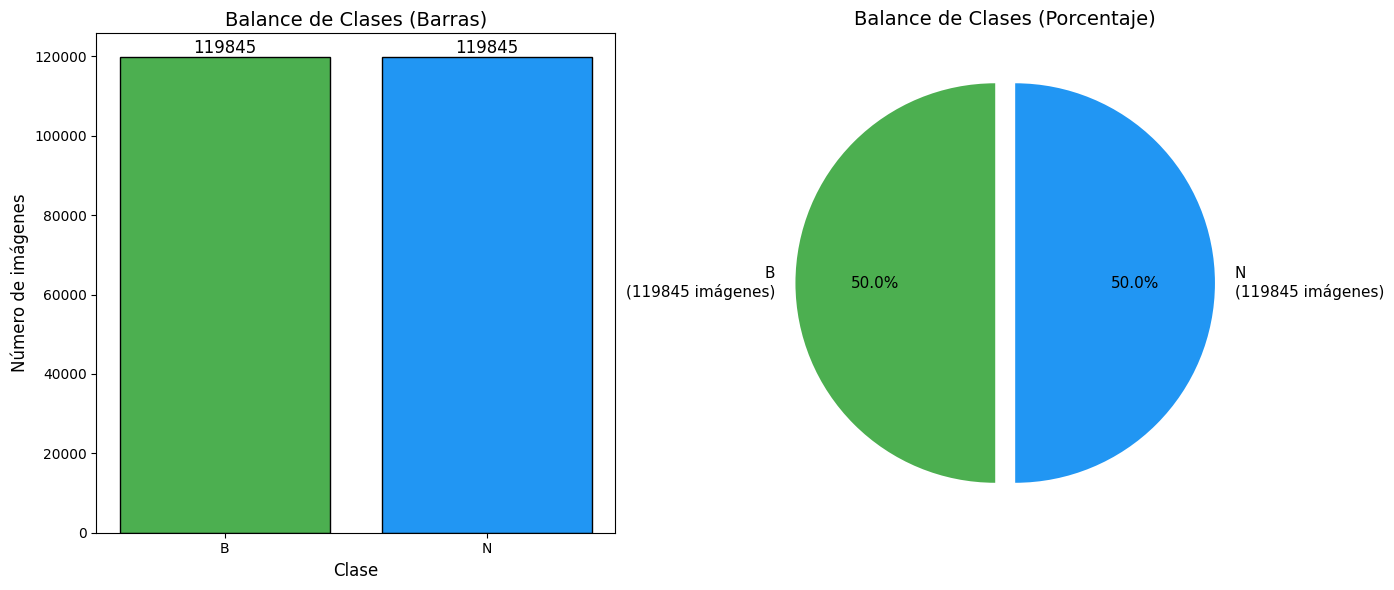

In [11]:
import matplotlib.pyplot as plt
import pandas as pd # Opcional, solo para ver los números bonitos

# 1. Obtener el dataset de entrenamiento desde el dataloader
train_dataset = dataloader['train'].dataset

# 2. Obtener los nombres de las clases (tus carpetas N y B)
nombres_clases = train_dataset.classes

# 3. Obtener las etiquetas (targets) de todas las imágenes del dataset
# ImageFolder guarda las etiquetas como índices (0, 1, 2...)
etiquetas = train_dataset.targets

# 4. Contar cuántas imágenes hay por cada clase
conteo_clases = []
for i in range(len(nombres_clases)):
    conteo = sum(1 for etiqueta in etiquetas if etiqueta == i)
    conteo_clases.append(conteo)

# 5. Imprimir los números en texto para tener el dato exacto
print("="*40)
print("DISTRIBUCIÓN DE CLASES EN EL CONJUNTO DE ENTRENAMIENTO")
print("="*40)
for i, nombre in enumerate(nombres_clases):
    print(f"Clase '{nombre}' (Índice {i}): {conteo_clases[i]} imágenes")
print(f"Total de imágenes: {sum(conteo_clases)}")
print("="*40)

# 6. Crear una figura con dos gráficos (Barras y Pastel)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- GRÁFICO DE BARRAS ---
axes[0].bar(nombres_clases, conteo_clases, color=['#4CAF50', '#2196F3'], edgecolor='black')
axes[0].set_title('Balance de Clases (Barras)', fontsize=14)
axes[0].set_ylabel('Número de imágenes', fontsize=12)
axes[0].set_xlabel('Clase', fontsize=12)
# Añadir el número encima de cada barra
for i, v in enumerate(conteo_clases):
    axes[0].text(i, v + 20, str(v), ha='center', va='bottom', fontsize=12, fontweight='bold')

# --- GRÁFICO DE PASTEL ---
axes[1].pie(conteo_clases, 
            labels=[f'{nombre}\n({conteo} imágenes)' for nombre, conteo in zip(nombres_clases, conteo_clases)],
            autopct='%1.1f%%', 
            colors=['#4CAF50', '#2196F3'],
            startangle=90,
            explode=[0.05, 0.05], # Separa ligeramente las rebanadas
            textprops={'fontsize': 11})
axes[1].set_title('Balance de Clases (Porcentaje)', fontsize=14)

# Ajustar el diseño y mostrar
plt.tight_layout()
plt.show()

In [4]:
# Para pruebas 

from torch.utils.data import Subset, random_split

# 1. Carga el dataset completo (como ya lo tenías)
full_train_dataset = torchvision.datasets.ImageFolder(
    root=PATH_TRAIN,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
)

# 2. Define cuántas imágenes quieres usar para la prueba (ej. 2000 en total)
# Si solo quieres 1000 imágenes, escribe 1000. 
# Si quieres el 10% del total, haz: int(len(full_train_dataset) * 0.1)
num_muestras_prueba = 2000 

# 3. Corta el dataset
# random_split divide el dataset en dos: una parte pequeña (prueba) y el resto (que no usaremos ahora)
_, subset_train_dataset = random_split(full_train_dataset, 
                                       [len(full_train_dataset) - num_muestras_prueba, num_muestras_prueba])

# 4. Crea el DataLoader con ese subset
dataloader_limitado = {
    'train': torch.utils.data.DataLoader(
        subset_train_dataset, # <--- Usamos el subset en lugar del full_train_dataset
        batch_size=32,
        shuffle=True,
        pin_memory=False
    ),
    'test': dataloader['test'] # Dejamos el test original o también puedes crear un subset para test
}

In [ ]:
def block(c_in, c_out, k=3, p=1, s=1, pk=2, ps=2):
    return torch.nn.Sequential(
        torch.nn.Conv2d(c_in, c_out, k, padding=p, stride=s),
        torch.nn.ReLU(),
        torch.nn.MaxPool2d(pk, stride=ps)
    )

In [7]:
class CNN(torch.nn.Module):
  def __init__(self, n_channels=3, n_outputs=2, input_size=200):
    super().__init__()
    self.conv1 = block(n_channels, 32)
    self.conv2 = block(32, 64)

    # 1. Crear un tensor falso del tamaño de tu entrada
    dummy_input = torch.zeros(1, n_channels, input_size, input_size)
    
    # 2. Pasarlo por las capas convolucionales para ver el tamaño final
    dummy_output = self.conv2(self.conv1(dummy_input))
    
    # 3. Aplanarlo y calcular el número de características para la capa Linear
    num_features = dummy_output.view(1, -1).shape[1]
    
    self.fc = torch.nn.Linear(num_features, n_outputs) # Ya no usas 196*50*50

    # self.fc = torch.nn.Linear(196*50*50, n_outputs)

  def forward(self, x):
    x = self.conv1(x)
    x = self.conv2(x)
    x = x.view(x.shape[0], -1)
    x = self.fc(x)
    return x

In [8]:
from tqdm import tqdm
import numpy as np

def fit(model, dataloader, epochs=1):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.CrossEntropyLoss()
    for epoch in range(1, epochs+1):
        model.train()
        train_loss, train_acc = [], []
        bar = tqdm(dataloader['train'])
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = model(X)
            loss = criterion(y_hat, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
            train_acc.append(acc)
            bar.set_description(f"loss {np.mean(train_loss):.5f} acc {np.mean(train_acc):.5f}")
        bar = tqdm(dataloader['test'])
        val_loss, val_acc = [], []
        model.eval()
        with torch.no_grad():
            for batch in bar:
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)
                val_loss.append(loss.item())
                acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
                val_acc.append(acc)
                bar.set_description(f"val_loss {np.mean(val_loss):.5f} val_acc {np.mean(val_acc):.5f}")
        print(f"Epoch {epoch}/{epochs} loss {np.mean(train_loss):.5f} val_loss {np.mean(val_loss):.5f} acc {np.mean(train_acc):.5f} val_acc {np.mean(val_acc):.5f}")

In [9]:
model = CNN()
fit(model, dataloader, epochs=2)

val_loss 0.37156 val_acc 0.84788: 100%|██████████| 523/523 [00:38<00:00, 13.65it/s]


Epoch 1/2 loss 0.21236 val_loss 0.37156 acc 0.91924 val_acc 0.84788


val_loss 0.41838 val_acc 0.82977: 100%|██████████| 523/523 [00:23<00:00, 21.82it/s]

Epoch 2/2 loss 0.16094 val_loss 0.41838 acc 0.94031 val_acc 0.82977


In [ ]:
# # Modelo de prueba
# model = CNN(n_outputs=2)
# fit(model, dataloader_limitado, epochs=3) # Prueba con 3 épocas rápidas


val_loss 0.43420 val_acc 0.80782: 100%|██████████| 523/523 [03:48<00:00,  2.29it/s]


Epoch 1/3 loss 0.84314 val_loss 0.43420 acc 0.78819 val_acc 0.80782


val_loss 0.43493 val_acc 0.80806: 100%|██████████| 523/523 [00:31<00:00, 16.83it/s]


Epoch 2/3 loss 0.30264 val_loss 0.43493 acc 0.87153 val_acc 0.80806


val_loss 0.43542 val_acc 0.81415: 100%|██████████| 523/523 [00:30<00:00, 17.22it/s]

Epoch 3/3 loss 0.26103 val_loss 0.43542 acc 0.89286 val_acc 0.81415


# METRICAS ENTRENAMIENTO

Calculando predicciones sobre el conjunto de TEST...


100%|██████████| 523/523 [00:21<00:00, 23.86it/s]



RESULTADOS EN EL CONJUNTO DE TEST
Accuracy (Exactitud): 82.97%
Precision (Promedio): 85.06%
Recall (Promedio)   : 82.97%
F1-Score (Promedio) : 82.72%


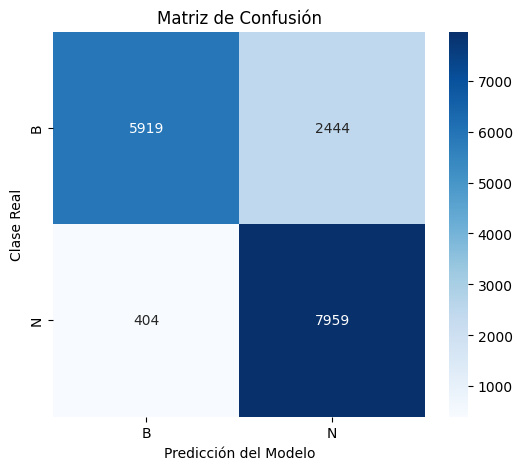


REPORTE DETALLADO POR CLASE (N y B):
              precision    recall  f1-score   support

           B       0.94      0.71      0.81      8363
           N       0.77      0.95      0.85      8363

    accuracy                           0.83     16726
   macro avg       0.85      0.83      0.83     16726
weighted avg       0.85      0.83      0.83     16726



In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Poner el modelo en modo evaluación y apagar el cálculo de gradientes
model.eval()
todas_predicciones = []
todas_etiquetas_reales = []

print("Calculando predicciones sobre el conjunto de TEST...")
with torch.no_grad():
    for X, y in tqdm(dataloader['test']):  # Usamos tqdm para ver el progreso
        X, y = X.to(device), y.to(device)
        
        # Obtener la salida del modelo
        salida = model(X)
        
        # Obtener la clase predicha (el índice con el valor más alto)
        _, predichos = torch.max(salida, 1)
        
        # Guardar las predicciones y las etiquetas reales
        todas_predicciones.extend(predichos.cpu().numpy())
        todas_etiquetas_reales.extend(y.cpu().numpy())

# Convertir las listas a arrays de numpy para usar con sklearn
y_true = np.array(todas_etiquetas_reales)
y_pred = np.array(todas_predicciones)

# Obtener los nombres de las clases (N y B según tus carpetas)
nombres_clases = dataloader['test'].dataset.classes

# ==========================================
# 2. CÁLCULO DE MÉTRICAS
# ==========================================

# Accuracy (Precisión global)
acc = accuracy_score(y_true, y_pred)

# Precision, Recall, F1-Score (por clase y promedio ponderado)
# average='weighted' tiene en cuenta el desbalanceo de clases (si hay más N que B)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Matriz de Confusión
cm = confusion_matrix(y_true, y_pred)

# ==========================================
# 3. IMPRESIÓN DE RESULTADOS EN PANTALLA
# ==========================================
print("\n" + "="*40)
print("RESULTADOS EN EL CONJUNTO DE TEST")
print("="*40)
print(f"Accuracy (Exactitud): {acc*100:.2f}%")
print(f"Precision (Promedio): {precision*100:.2f}%")
print(f"Recall (Promedio)   : {recall*100:.2f}%")
print(f"F1-Score (Promedio) : {f1*100:.2f}%")
print("="*40)

# ==========================================
# 4. VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN
# ==========================================
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real')
plt.title('Matriz de Confusión')
plt.show()

# ==========================================
# 5. REPORTE DETALLADO POR CLASE (Opcional)
# ==========================================
print("\n" + "="*40)
print("REPORTE DETALLADO POR CLASE (N y B):")
print("="*40)
# Esto te dará la precisión, recall y f1 individual para cada clase
from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=nombres_clases))

# CODIGO PARA PROBAR EL MODELO

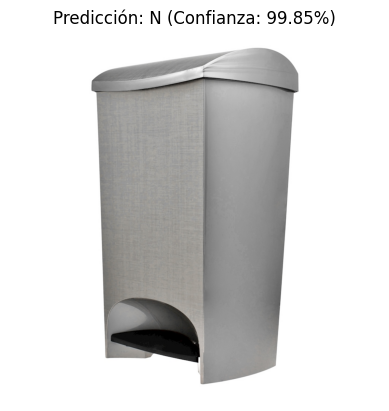

La red predice que es: N
Con una confianza del: 99.85%
Distribución completa de probabilidades:
  B: 0.15%
  N: 99.85%


In [12]:
from PIL import Image
import matplotlib.pyplot as plt

# 1. Ruta de la imagen que quieres probar (cambia esta ruta)
ruta_imagen_prueba = 'C:/Users/aaran/Downloads/ML Testing Img/plastico2.jpg'

# 2. Definir las transformaciones (DEBEN SER LAS MISMAS que usaste en entrenamiento)
test_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((200, 200)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 3. Cargar y transformar la imagen
imagen_original = Image.open(ruta_imagen_prueba).convert('RGB') # Asegura 3 canales
imagen_tensor = test_transform(imagen_original)
imagen_tensor = imagen_tensor.unsqueeze(0) # Agrega la dimensión del batch: [1, 3, 200, 200]

# 4. Poner el modelo en modo evaluación y pasar la imagen
model.eval() # Desactiva Dropout/BatchNorm (importante)
with torch.no_grad():
    salida = model(imagen_tensor.to(device))

# 5. Interpretar el resultado
# Obtener la probabilidad usando Softmax (opcional, pero recomendado para ver confianza)
probabilidades = torch.nn.functional.softmax(salida, dim=1)
confianza, pred_idx = torch.max(probabilidades, 1)

# 6. Mapear el índice de la clase a su nombre real
# Obtén la lista de nombres de las carpetas de tu TRAIN
nombres_clases = dataloader['train'].dataset.classes 
clase_predicha = nombres_clases[pred_idx.item()]

# 7. Mostrar resultados
plt.imshow(imagen_original)
plt.title(f"Predicción: {clase_predicha} (Confianza: {confianza.item()*100:.2f}%)")
plt.axis('off')
plt.show()

print(f"La red predice que es: {clase_predicha}")
print(f"Con una confianza del: {confianza.item()*100:.2f}%")
print("Distribución completa de probabilidades:")
for i, nombre in enumerate(nombres_clases):
    print(f"  {nombre}: {probabilidades[0][i].item()*100:.2f}%")

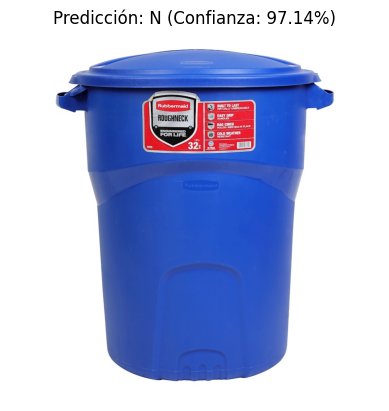

La red predice que es: N
Con una confianza del: 97.14%
Distribución completa de probabilidades:
  B: 2.86%
  N: 97.14%


In [13]:
from PIL import Image
import matplotlib.pyplot as plt

# 1. Ruta de la imagen que quieres probar (cambia esta ruta)
ruta_imagen_prueba = 'C:/Users/aaran/Downloads/ML Testing Img/plastico1.jpg'

# 2. Definir las transformaciones (DEBEN SER LAS MISMAS que usaste en entrenamiento)
test_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((200, 200)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 3. Cargar y transformar la imagen
imagen_original = Image.open(ruta_imagen_prueba).convert('RGB') # Asegura 3 canales
imagen_tensor = test_transform(imagen_original)
imagen_tensor = imagen_tensor.unsqueeze(0) # Agrega la dimensión del batch: [1, 3, 200, 200]

# 4. Poner el modelo en modo evaluación y pasar la imagen
model.eval() # Desactiva Dropout/BatchNorm (importante)
with torch.no_grad():
    salida = model(imagen_tensor.to(device))

# 5. Interpretar el resultado
# Obtener la probabilidad usando Softmax (opcional, pero recomendado para ver confianza)
probabilidades = torch.nn.functional.softmax(salida, dim=1)
confianza, pred_idx = torch.max(probabilidades, 1)

# 6. Mapear el índice de la clase a su nombre real
# Obtén la lista de nombres de las carpetas de tu TRAIN
nombres_clases = dataloader['train'].dataset.classes 
clase_predicha = nombres_clases[pred_idx.item()]

# 7. Mostrar resultados
plt.imshow(imagen_original)
plt.title(f"Predicción: {clase_predicha} (Confianza: {confianza.item()*100:.2f}%)")
plt.axis('off')
plt.show()

print(f"La red predice que es: {clase_predicha}")
print(f"Con una confianza del: {confianza.item()*100:.2f}%")
print("Distribución completa de probabilidades:")
for i, nombre in enumerate(nombres_clases):
    print(f"  {nombre}: {probabilidades[0][i].item()*100:.2f}%")

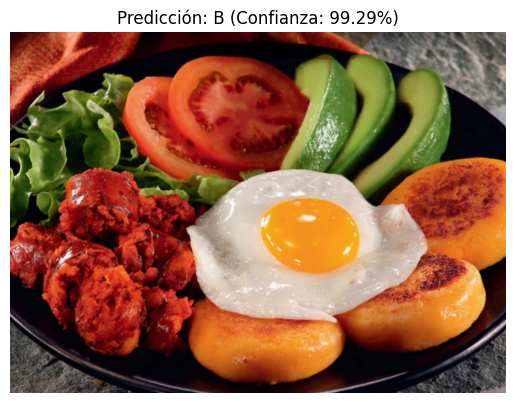

La red predice que es: B
Con una confianza del: 99.29%
Distribución completa de probabilidades:
  B: 99.29%
  N: 0.71%


In [13]:
from PIL import Image
import matplotlib.pyplot as plt

# 1. Ruta de la imagen que quieres probar (cambia esta ruta)
ruta_imagen_prueba = 'C:/Users/aaran/Downloads/ML Testing Img/Revista-Maxi-Llapingachos-con-chorizo_Mediano.jpg'

# 2. Definir las transformaciones (DEBEN SER LAS MISMAS que usaste en entrenamiento)
test_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((200, 200)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 3. Cargar y transformar la imagen
imagen_original = Image.open(ruta_imagen_prueba).convert('RGB') # Asegura 3 canales
imagen_tensor = test_transform(imagen_original)
imagen_tensor = imagen_tensor.unsqueeze(0) # Agrega la dimensión del batch: [1, 3, 200, 200]

# 4. Poner el modelo en modo evaluación y pasar la imagen
model.eval() # Desactiva Dropout/BatchNorm (importante)
with torch.no_grad():
    salida = model(imagen_tensor.to(device))

# 5. Interpretar el resultado
# Obtener la probabilidad usando Softmax (opcional, pero recomendado para ver confianza)
probabilidades = torch.nn.functional.softmax(salida, dim=1)
confianza, pred_idx = torch.max(probabilidades, 1)

# 6. Mapear el índice de la clase a su nombre real
# Obtén la lista de nombres de las carpetas de tu TRAIN
nombres_clases = dataloader['train'].dataset.classes 
clase_predicha = nombres_clases[pred_idx.item()]

# 7. Mostrar resultados
plt.imshow(imagen_original)
plt.title(f"Predicción: {clase_predicha} (Confianza: {confianza.item()*100:.2f}%)")
plt.axis('off')
plt.show()

print(f"La red predice que es: {clase_predicha}")
print(f"Con una confianza del: {confianza.item()*100:.2f}%")
print("Distribución completa de probabilidades:")
for i, nombre in enumerate(nombres_clases):
    print(f"  {nombre}: {probabilidades[0][i].item()*100:.2f}%")

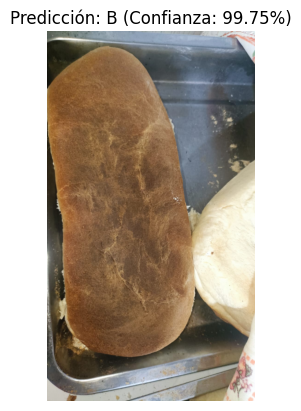

La red predice que es: B
Con una confianza del: 99.75%
Distribución completa de probabilidades:
  B: 99.75%
  N: 0.25%


In [15]:
from PIL import Image
import matplotlib.pyplot as plt

# 1. Ruta de la imagen que quieres probar (cambia esta ruta)
ruta_imagen_prueba = 'C:/Users/aaran/Downloads/ML Testing Img/pan.jpeg'

# 2. Definir las transformaciones (DEBEN SER LAS MISMAS que usaste en entrenamiento)
test_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((200, 200)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 3. Cargar y transformar la imagen
imagen_original = Image.open(ruta_imagen_prueba).convert('RGB') # Asegura 3 canales
imagen_tensor = test_transform(imagen_original)
imagen_tensor = imagen_tensor.unsqueeze(0) # Agrega la dimensión del batch: [1, 3, 200, 200]

# 4. Poner el modelo en modo evaluación y pasar la imagen
model.eval() # Desactiva Dropout/BatchNorm (importante)
with torch.no_grad():
    salida = model(imagen_tensor.to(device))

# 5. Interpretar el resultado
# Obtener la probabilidad usando Softmax (opcional, pero recomendado para ver confianza)
probabilidades = torch.nn.functional.softmax(salida, dim=1)
confianza, pred_idx = torch.max(probabilidades, 1)

# 6. Mapear el índice de la clase a su nombre real
# Obtén la lista de nombres de las carpetas de tu TRAIN
nombres_clases = dataloader['train'].dataset.classes 
clase_predicha = nombres_clases[pred_idx.item()]

# 7. Mostrar resultados
plt.imshow(imagen_original)
plt.title(f"Predicción: {clase_predicha} (Confianza: {confianza.item()*100:.2f}%)")
plt.axis('off')
plt.show()

print(f"La red predice que es: {clase_predicha}")
print(f"Con una confianza del: {confianza.item()*100:.2f}%")
print("Distribución completa de probabilidades:")
for i, nombre in enumerate(nombres_clases):
    print(f"  {nombre}: {probabilidades[0][i].item()*100:.2f}%")

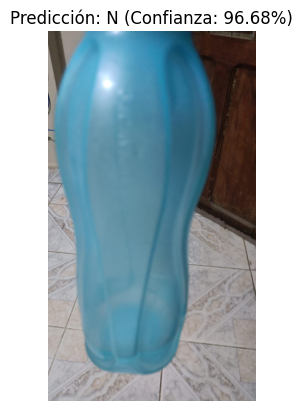

La red predice que es: N
Con una confianza del: 96.68%
Distribución completa de probabilidades:
  B: 3.32%
  N: 96.68%


In [16]:
from PIL import Image
import matplotlib.pyplot as plt

# 1. Ruta de la imagen que quieres probar (cambia esta ruta)
ruta_imagen_prueba = 'C:/Users/aaran/Downloads/ML Testing Img/botella_plastico.jpeg'

# 2. Definir las transformaciones (DEBEN SER LAS MISMAS que usaste en entrenamiento)
test_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((200, 200)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 3. Cargar y transformar la imagen
imagen_original = Image.open(ruta_imagen_prueba).convert('RGB') # Asegura 3 canales
imagen_tensor = test_transform(imagen_original)
imagen_tensor = imagen_tensor.unsqueeze(0) # Agrega la dimensión del batch: [1, 3, 200, 200]

# 4. Poner el modelo en modo evaluación y pasar la imagen
model.eval() # Desactiva Dropout/BatchNorm (importante)
with torch.no_grad():
    salida = model(imagen_tensor.to(device))

# 5. Interpretar el resultado
# Obtener la probabilidad usando Softmax (opcional, pero recomendado para ver confianza)
probabilidades = torch.nn.functional.softmax(salida, dim=1)
confianza, pred_idx = torch.max(probabilidades, 1)

# 6. Mapear el índice de la clase a su nombre real
# Obtén la lista de nombres de las carpetas de tu TRAIN
nombres_clases = dataloader['train'].dataset.classes 
clase_predicha = nombres_clases[pred_idx.item()]

# 7. Mostrar resultados
plt.imshow(imagen_original)
plt.title(f"Predicción: {clase_predicha} (Confianza: {confianza.item()*100:.2f}%)")
plt.axis('off')
plt.show()

print(f"La red predice que es: {clase_predicha}")
print(f"Con una confianza del: {confianza.item()*100:.2f}%")
print("Distribución completa de probabilidades:")
for i, nombre in enumerate(nombres_clases):
    print(f"  {nombre}: {probabilidades[0][i].item()*100:.2f}%")

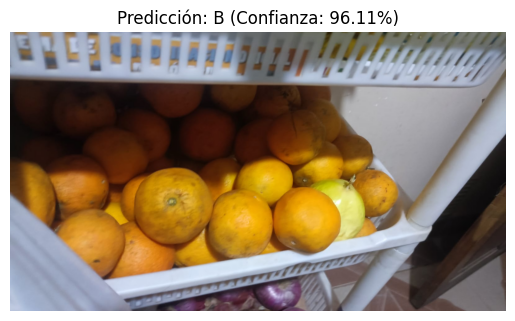

La red predice que es: B
Con una confianza del: 96.11%
Distribución completa de probabilidades:
  B: 96.11%
  N: 3.89%


In [17]:
from PIL import Image
import matplotlib.pyplot as plt

# 1. Ruta de la imagen que quieres probar (cambia esta ruta)
ruta_imagen_prueba = 'C:/Users/aaran/Downloads/ML Testing Img/naranjas.jpeg'

# 2. Definir las transformaciones (DEBEN SER LAS MISMAS que usaste en entrenamiento)
test_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((200, 200)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 3. Cargar y transformar la imagen
imagen_original = Image.open(ruta_imagen_prueba).convert('RGB') # Asegura 3 canales
imagen_tensor = test_transform(imagen_original)
imagen_tensor = imagen_tensor.unsqueeze(0) # Agrega la dimensión del batch: [1, 3, 200, 200]

# 4. Poner el modelo en modo evaluación y pasar la imagen
model.eval() # Desactiva Dropout/BatchNorm (importante)
with torch.no_grad():
    salida = model(imagen_tensor.to(device))

# 5. Interpretar el resultado
# Obtener la probabilidad usando Softmax (opcional, pero recomendado para ver confianza)
probabilidades = torch.nn.functional.softmax(salida, dim=1)
confianza, pred_idx = torch.max(probabilidades, 1)

# 6. Mapear el índice de la clase a su nombre real
# Obtén la lista de nombres de las carpetas de tu TRAIN
nombres_clases = dataloader['train'].dataset.classes 
clase_predicha = nombres_clases[pred_idx.item()]

# 7. Mostrar resultados
plt.imshow(imagen_original)
plt.title(f"Predicción: {clase_predicha} (Confianza: {confianza.item()*100:.2f}%)")
plt.axis('off')
plt.show()

print(f"La red predice que es: {clase_predicha}")
print(f"Con una confianza del: {confianza.item()*100:.2f}%")
print("Distribución completa de probabilidades:")
for i, nombre in enumerate(nombres_clases):
    print(f"  {nombre}: {probabilidades[0][i].item()*100:.2f}%")

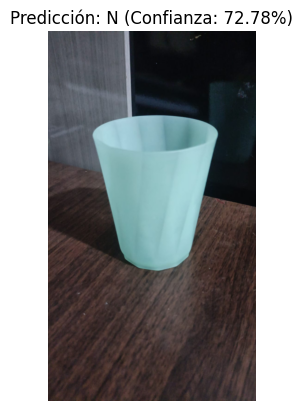

La red predice que es: N
Con una confianza del: 72.78%
Distribución completa de probabilidades:
  B: 27.22%
  N: 72.78%


In [18]:
from PIL import Image
import matplotlib.pyplot as plt

# 1. Ruta de la imagen que quieres probar (cambia esta ruta)
ruta_imagen_prueba = 'C:/Users/aaran/Downloads/ML Testing Img/vaso_plastico.jpeg'

# 2. Definir las transformaciones (DEBEN SER LAS MISMAS que usaste en entrenamiento)
test_transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((200, 200)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 3. Cargar y transformar la imagen
imagen_original = Image.open(ruta_imagen_prueba).convert('RGB') # Asegura 3 canales
imagen_tensor = test_transform(imagen_original)
imagen_tensor = imagen_tensor.unsqueeze(0) # Agrega la dimensión del batch: [1, 3, 200, 200]

# 4. Poner el modelo en modo evaluación y pasar la imagen
model.eval() # Desactiva Dropout/BatchNorm (importante)
with torch.no_grad():
    salida = model(imagen_tensor.to(device))

# 5. Interpretar el resultado
# Obtener la probabilidad usando Softmax (opcional, pero recomendado para ver confianza)
probabilidades = torch.nn.functional.softmax(salida, dim=1)
confianza, pred_idx = torch.max(probabilidades, 1)

# 6. Mapear el índice de la clase a su nombre real
# Obtén la lista de nombres de las carpetas de tu TRAIN
nombres_clases = dataloader['train'].dataset.classes 
clase_predicha = nombres_clases[pred_idx.item()]

# 7. Mostrar resultados
plt.imshow(imagen_original)
plt.title(f"Predicción: {clase_predicha} (Confianza: {confianza.item()*100:.2f}%)")
plt.axis('off')
plt.show()

print(f"La red predice que es: {clase_predicha}")
print(f"Con una confianza del: {confianza.item()*100:.2f}%")
print("Distribución completa de probabilidades:")
for i, nombre in enumerate(nombres_clases):
    print(f"  {nombre}: {probabilidades[0][i].item()*100:.2f}%")

In [ ]:
# guardar modelo

PATH = './checkpoint_pesos.pt'
torch.save(model.state_dict(), PATH)

In [21]:
#Instanciar modelo
class CNN(torch.nn.Module):
  def __init__(self, n_channels=3, n_outputs=2, input_size=200):
    super().__init__()
    self.conv1 = block(n_channels, 32)
    self.conv2 = block(32, 64)

    # 1. Crear un tensor falso del tamaño de tu entrada
    dummy_input = torch.zeros(1, n_channels, input_size, input_size)
    
    # 2. Pasarlo por las capas convolucionales para ver el tamaño final
    dummy_output = self.conv2(self.conv1(dummy_input))
    
    # 3. Aplanarlo y calcular el número de características para la capa Linear
    num_features = dummy_output.view(1, -1).shape[1]
    
    self.fc = torch.nn.Linear(num_features, n_outputs) # Ya no usas 196*50*50

    # self.fc = torch.nn.Linear(196*50*50, n_outputs)


model = CNN()

In [20]:
# cargar modelo
PATH = './checkpoint_pesos.pt'

model.load_state_dict(torch.load(PATH))
model.eval()

CNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=160000, out_features=2, bias=True)
)